# Optimal Actuator Load Sharing: When Enforcing Force Balance Slows Optimization
**MAE 598 Design Optimization | Project 2: Ill-Conditioned Optimization**

**Team:** TheDESIGNOptimizers | [Team repository](https://github.com/jfandrew-awesome/TheDESIGNOptimizers)

**Mechanism: family G, quadratic penalty reformulation.** Two identical, bidirectional actuators must share a prescribed axial load. A larger force-balance penalty creates a narrow valley: gradient descent becomes slow even though the physical allocation problem is simple. An augmented Lagrangian enforces balance with a fixed, moderate penalty.

This is an idealized engineering case study, not experimental data. All numerical results below are generated by the included code. The two-dimensional quadratic is **derived from actuator effort and physical force balance**, rather than constructed by prescribing a rotated Hessian and its condition number.

**How to run:** install `requirements.txt` in Python 3.12, then run all cells in order, or execute `python run_notebook.py`. This notebook contains the entire report and all model/solver code; no data download is needed. It saves supporting figures and tables under `results/`. A fixed seed is specified, although the main experiments are deterministic. See `README.md` for setup and submission steps.

**Evidence map:** Section 3 contains the intrinsic test (D2); Section 4 contains spectra, baseline curves, and contour paths (D1/D3); Section 5 contains the remedy and a common-accuracy comparison (D4). Sections 1, 2, and 6 document motivation, formulation, and assumptions.

## 1. Problem identification and motivation

Consider two parallel linear actuators assisting a guided lifting carriage. A guide carries lateral loads and moments; the actuator allocation model concerns only their combined axial force. The controller must produce a specified upward force while distributing actuator effort efficiently. An unnecessarily unequal split increases a quadratic effort cost for otherwise identical actuators.

For an idealized current-controlled actuator, assume $F_i=K_f I_i$ and resistive loss $P_i=R I_i^2$. Then total loss is $P=c(F_1^2+F_2^2)$, where $c=R/K_f^2>0$. This motivates the quadratic cost; we do not claim to model total electrical input power, efficiency maps, or transient dynamics.

Use a reference demand $F_{\mathrm{ref}}=1000\ \mathrm{N}$ and normalized forces $q_i=F_i/F_{\mathrm{ref}}$. The reference power is $P_{\mathrm{ref}}=2cF_{\mathrm{ref}}^2$, giving the dimensionless cost $J=P/P_{\mathrm{ref}}=(q_1^2+q_2^2)/2$. The exact force scale and positive common loss coefficient do not affect the normalized optimizer or condition number.

**Engineering question:** How can a controller enforce accurate total force without making its optimization unnecessarily difficult? This project isolates the numerical effect of replacing force balance by a large penalty and demonstrates a remedy.

## 2. Formulation

| Quantity | Definition | Units / dimension | Bounds and type |
|---|---|---|---|
| $F=(F_1,F_2)^\top$ | Physical actuator forces | N; 2-vector | Continuous, $F_i\in\mathbb R$; ideal bidirectional actuators |
| $q=F/F_{\mathrm{ref}}$ | Decision variables used in computation | Dimensionless; 2-vector | Continuous, $q_i\in\mathbb R$; no capacity limits in this model |
| $a=(1,1)^\top$ | Force-summing vector | Dimensionless; 2-vector | Fixed |
| $b=1$ | Normalized required total force | Dimensionless; scalar | Fixed |
| $\rho>0$ | Penalty parameter | Dimensionless; scalar | Algorithm parameter, not a design variable |
| $y$ | Multiplier of normalized force balance | Dimensionless; scalar | Unrestricted dual variable |

### Original constrained problem

$$\boxed{\min_{q\in\mathbb R^2}J(q)=\frac12q^\top q\quad\text{subject to}\quad g(q)=a^\top q-1=0.}$$

There are no other constraints. This is a continuous, deterministic, equality-constrained, strictly convex quadratic program with a unique minimizer. Its Lagrangian is $\mathcal L(q,y)=J(q)+y g(q)$. The Karush-Kuhn-Tucker (KKT) equations are

$$q+ya=0,\qquad a^\top q=1.$$

Thus $q^\star=(1/2,1/2)^\top$, $y^\star=-1/2$, and $J^\star=1/4$. Each actuator supplies $500\ \mathrm N$. The original objective Hessian is $I$; its poor conditioning below is introduced by the **penalty reformulation**, not by disparate units or a difficult physical optimum.

### Quadratic penalty problem

$$F_\rho(q)=\frac12q^\top q+\frac\rho2(a^\top q-1)^2,\qquad \min_{q\in\mathbb R^2}F_\rho(q).$$

$$\nabla F_\rho(q)=q+\rho(a^\top q-1)a,\qquad H_\rho=I+\rho aa^\top.$$

For finite $\rho$, this unconstrained, strictly convex quadratic has the unique minimizer

$$q_\rho^\star=\frac{\rho}{1+2\rho}a,\quad g(q_\rho^\star)=-\frac1{1+2\rho},\quad F_\rho^\star=\frac{\rho}{2(1+2\rho)}.$$

The penalty minimizer is **not exactly feasible**. To make $|g|\le\epsilon$ even with an exact penalty solve, one needs $\rho\ge(\epsilon^{-1}-1)/2$. Larger penalties reduce bias but worsen conditioning. We keep the distinction between $F_\rho^\star$ and the constrained value $J^\star$ throughout.

In [1]:
from pathlib import Path
import csv
import json
import platform
import time
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter
from IPython.display import display, Image, Markdown

SEED = 598
rng = np.random.default_rng(SEED)
OUT = Path('results')
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110,
                     'savefig.dpi': 170, 'axes.titleweight': 'bold'})
COLORS = {'penalty': '#bd492d', 'alm': '#167d9a', 'scale': '#7666a1'}
a = np.ones(2)
q_star = 0.5 * a
y_star = -0.5
q0 = np.array([0.9, -0.1])  # excites both force-sum and load-redistribution modes
F_REF = 1000.0

def objective(q): return 0.5 * np.dot(q, q)
def constraint(q): return np.sum(q) - 1.0
def penalty(q, rho): return objective(q) + 0.5 * rho * constraint(q)**2
def penalty_grad(q, rho): return q + rho * constraint(q) * a
def hessian(rho): return np.eye(2) + rho * np.outer(a, a)
def penalty_solution(rho): return (rho / (1.0 + 2.0 * rho)) * a

# Adapted from the assignment diagnostic helpers, with SPD validation.
def spectrum(H):
    ev = np.linalg.eigvalsh(H)
    if ev[0] <= 0:
        raise ValueError('The condition-number interpretation requires SPD H.')
    return ev, ev[-1] / ev[0]

def cond_after_diagonal_rescale(H):
    d = np.sqrt(np.diag(H))
    return spectrum(H / np.outer(d, d))[1]

def show_save(fig, stem):
    fig.savefig(OUT / f'{stem}.png', bbox_inches='tight')
    display(Image(filename=str(OUT / f'{stem}.png')))
    plt.close(fig)

def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---']*len(headers))
                     + '|\n' + '\n'.join('| ' + ' | '.join(map(str, r)) + ' |' for r in rows)))

def save_csv(name, headers, rows):
    with (OUT / name).open('w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        writer.writerows(rows)

def readable_work_axis(axis):
    axis.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
    axis.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value/1000:g}k' if abs(value)>=1000 else f'{value:g}'))

print(f'Python {platform.python_version()} | NumPy {np.__version__} | Matplotlib {matplotlib.__version__}')
print(f'Constrained optimum: q*={q_star}, forces={F_REF*q_star} N, J*={objective(q_star):.4f}')

Python 3.12.14 | NumPy 2.3.5 | Matplotlib 3.11.2
Constrained optimum: q*=[0.5 0.5], forces=[500. 500.] N, J*=0.2500


## 3. Ill-conditioning mechanism

### Family G: stiffness normal to a constraint

The Hessian is

$$H_\rho=\begin{bmatrix}1+\rho&\rho\\\rho&1+\rho\end{bmatrix}.$$

The normalized eigenvectors are $v_t=(1,-1)^\top/\sqrt2$ and $v_n=(1,1)^\top/\sqrt2$. Motion along $v_t$ redistributes load without changing its sum; its eigenvalue is $1$. Motion along $v_n$ changes total force and incurs the penalty; its eigenvalue is $1+2\rho$. Hence

$$\mu=1,\quad L=1+2\rho,\quad\boxed{\kappa(H_\rho)=1+2\rho.}$$

This gives a mechanical interpretation of the narrow valley: redistribution remains soft while total-force changes become stiff.

### D2: both parts of the intrinsic test

1. **Structural growth:** $\kappa$ grows linearly with the enforcement parameter $\rho$.
2. **Survival under Jacobi rescaling:** $D=\operatorname{diag}(H_\rho)=(1+\rho)I$, so $D^{-1/2}H_\rho D^{-1/2}=H_\rho/(1+\rho)$. Both eigenvalues receive the same factor, leaving their ratio unchanged.

Therefore this problem meets the assignment's definition of intrinsic ill-conditioning. It is not a claim that conditioning is invariant under every possible coordinate transformation; a transformation that mixes coordinates can change it.

**Hand check at $\rho=1$:** $H=\left[\begin{smallmatrix}2&1\\1&2\end{smallmatrix}\right]$ has eigenvalues $1,3$, hence $\kappa=3$. Jacobi scaling gives eigenvalues $1/2,3/2$, again with $\kappa=3$. The penalty solution is $(1/3,1/3)$, with force deficit $1/3$.

| Penalty rho | Condition number | After Jacobi | Exact force deficit / demand |
|---|---|---|---|
| 1 | 3 | 3 | 0.333333 |
| 10 | 21 | 21 | 0.047619 |
| 100 | 201 | 201 | 0.00497512 |
| 1000 | 2001 | 2001 | 0.00049975 |
| 10000 | 20001 | 20001 | 4.99975e-05 |
| 1000000 | 2000001 | 2000001 | 5e-07 |

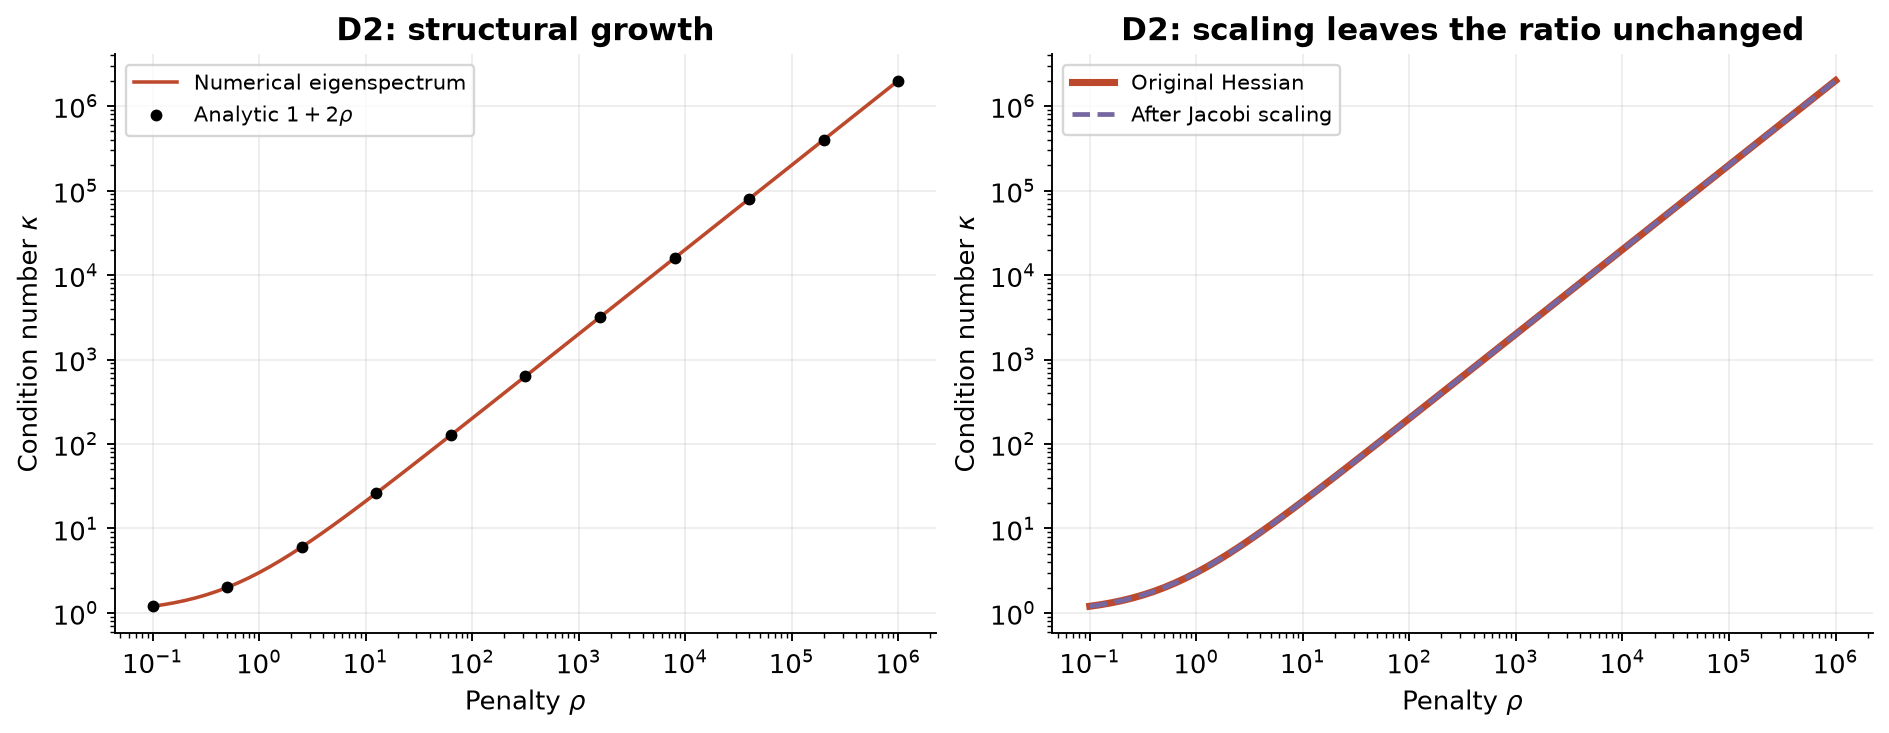

In [2]:
rho_grid = np.logspace(-1, 6, 71)
kappas = np.array([spectrum(hessian(r))[1] for r in rho_grid])
kappas_j = np.array([cond_after_diagonal_rescale(hessian(r)) for r in rho_grid])
np.testing.assert_allclose(kappas, 1+2*rho_grid, rtol=1e-9)
np.testing.assert_allclose(kappas_j, kappas, rtol=1e-9)

rho_table = [1, 10, 100, 1000, 10000, 1000000]
rows = [[r, f'{spectrum(hessian(r))[1]:.0f}',
         f'{cond_after_diagonal_rescale(hessian(r)):.0f}',
         f'{1/(1+2*r):.6g}'] for r in rho_table]
table(['Penalty rho', 'Condition number', 'After Jacobi', 'Exact force deficit / demand'], rows)
save_csv('intrinsic_test.csv', ['rho', 'kappa', 'kappa_jacobi', 'exact_relative_force_deficit'], rows)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), layout='constrained')
ax[0].loglog(rho_grid, kappas, color=COLORS['penalty'], label='Numerical eigenspectrum')
ax[0].loglog(rho_grid[::7], (1+2*rho_grid)[::7], 'ko', ms=4, label=r'Analytic $1+2\rho$')
ax[0].set(xlabel=r'Penalty $\rho$', ylabel=r'Condition number $\kappa$', title='D2: structural growth')
ax[1].loglog(rho_grid, kappas, color=COLORS['penalty'], lw=3, label='Original Hessian')
ax[1].loglog(rho_grid, kappas_j, '--', color=COLORS['scale'], lw=2, label='After Jacobi scaling')
ax[1].set(xlabel=r'Penalty $\rho$', ylabel=r'Condition number $\kappa$', title='D2: scaling leaves the ratio unchanged')
for axis in ax: axis.grid(alpha=.22); axis.legend(fontsize=9)
show_save(fig, 'd2_intrinsic_test')

## 4. Effect of ill-conditioning

### D1: spectrum

There are only two eigenvalues. The logarithmic spectrum plot deliberately shows both, rather than suggesting an unmeasured high-dimensional spectrum. Increasing $\rho$ separates normal and tangential curvature.

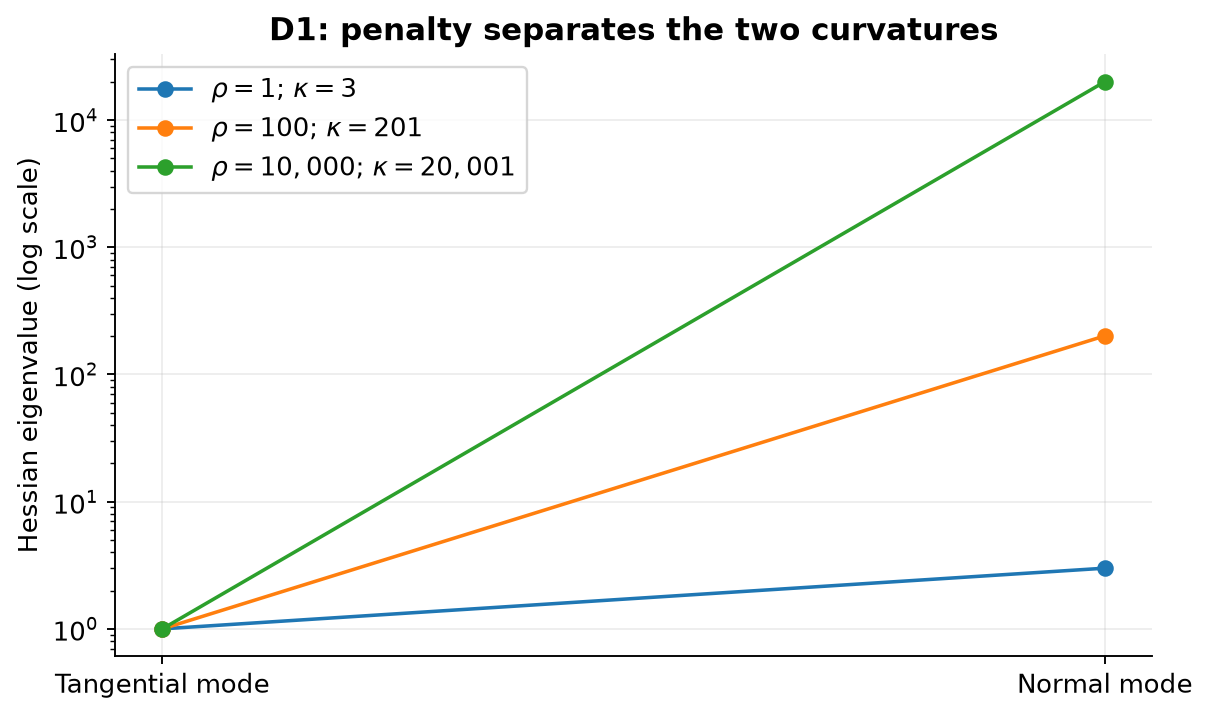

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.1), layout='constrained')
for rho in [1, 100, 10000]:
    ev, kappa = spectrum(hessian(rho))
    ax.semilogy([1, 2], ev, 'o-', label=fr'$\rho={rho:,}$; $\kappa={kappa:,.0f}$')
ax.set(xticks=[1, 2], xticklabels=['Tangential mode', 'Normal mode'],
       ylabel='Hessian eigenvalue (log scale)', title='D1: penalty separates the two curvatures')
ax.grid(alpha=.22); ax.legend()
show_save(fig, 'd1_spectrum')

### D3: gradient descent baseline and a hand-derived iteration count

Use $q_{k+1}=q_k-\alpha\nabla F_\rho(q_k)$ with the optimal constant step for this SPD quadratic,

$$\alpha=\frac{2}{L+\mu}=\frac1{1+\rho}.$$

The two eigenvalues of the iteration matrix are $+r$ and $-r$, where $r=\rho/(1+\rho)=(\kappa-1)/(\kappa+1)$. Thus, in exact arithmetic,

$$\frac{\|\nabla F_\rho(q_k)\|_2}{\|\nabla F_\rho(q_0)\|_2}=r^k,\qquad
\frac{F_\rho(q_k)-F_\rho^\star}{F_\rho(q_0)-F_\rho^\star}=r^{2k}.$$

For a relative gradient tolerance $\tau$, the predicted number of **updates** is $\lceil\log(\tau)/\log(r)\rceil$, growing linearly in $\rho$ for fixed $\tau$. At $\rho=1$ and $\tau=10^{-6}$, $r=1/2$; $2^{-19}>10^{-6}$ and $2^{-20}<10^{-6}$, so exactly **20 updates** are required. From $q_0=(0.9,-0.1)$, the first gradient is $(0.7,-0.3)$ and the first iterate is $(0.55,0.05)$.

The unequal initial forces excite both eigenmodes. Starting at $q_1=q_2$ with a step that eliminates the normal error could hide the slow redistribution mode. Our baseline uses an analytically favorable stable step, rather than an intentionally poor choice.

For numerical stability, the objective gap is evaluated as $\tfrac12(q-q_\rho^\star)^\top H_\rho(q-q_\rho^\star)$, avoiding subtraction of nearly equal function values. All D3 runs solve their own finite-penalty objective; they do **not** yet meet a common constrained-problem accuracy.

| rho | kappa | Predicted updates | Measured updates | Gradient evaluations |
|---|---|---|---|---|
| 1 | 3 | 20 | 20 | 21 |
| 10 | 21 | 145 | 145 | 146 |
| 100 | 201 | 1389 | 1389 | 1390 |
| 1000 | 2001 | 13823 | 13823 | 13824 |
| 10000 | 20001 | 138163 | 138163 | 138164 |

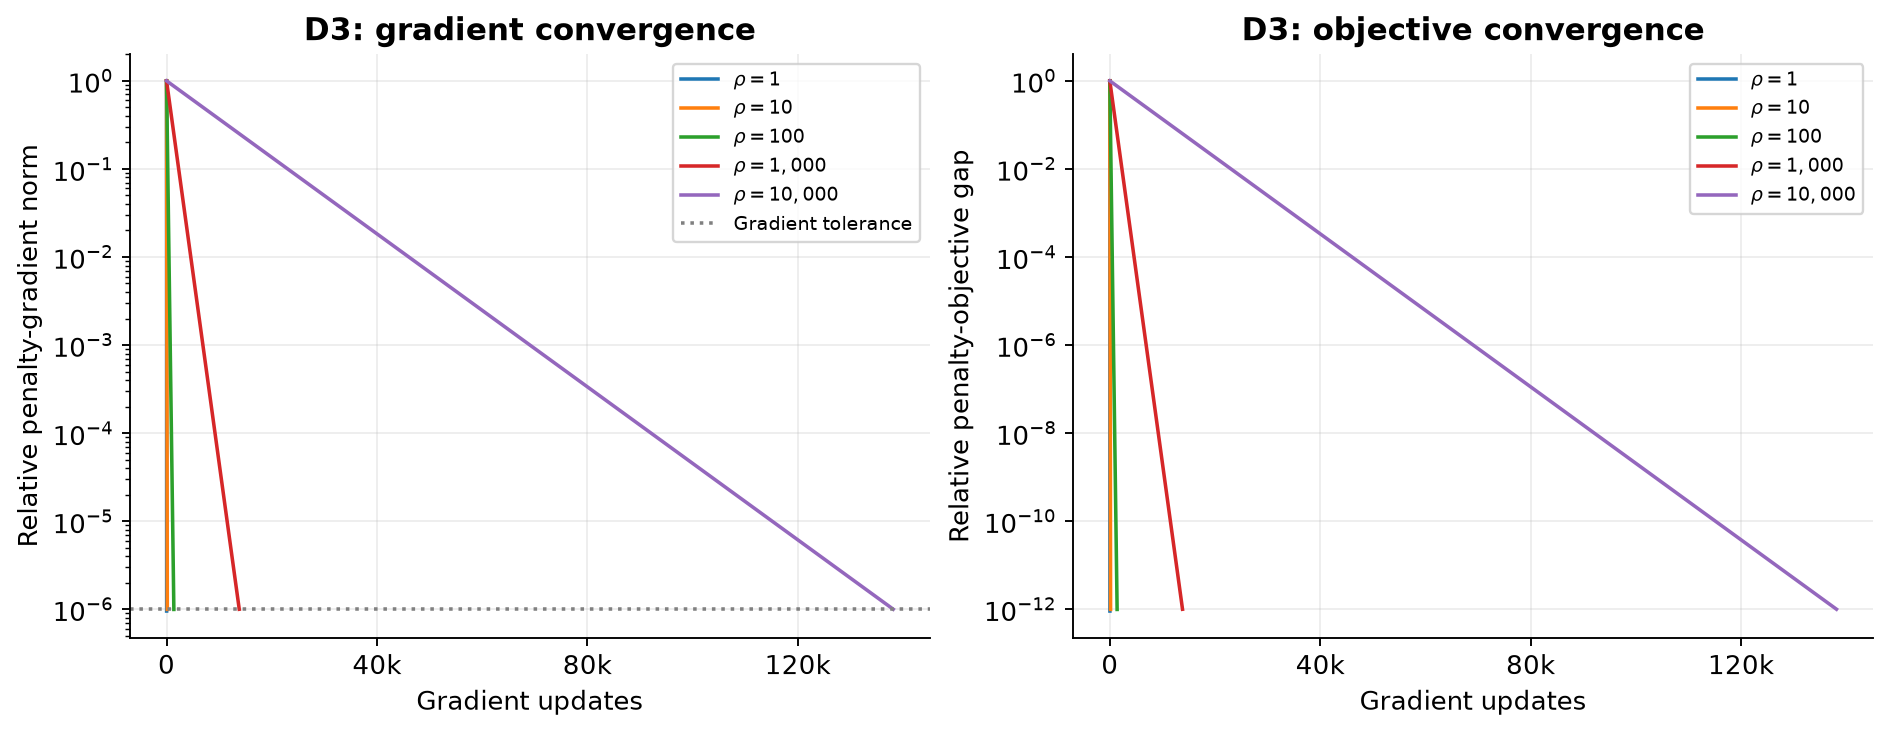

In [4]:
def gradient_descent(grad, x0, step, tol, maxit):
    """Assignment helper adapted to count updates and gradient evaluations exactly."""
    x = np.array(x0, dtype=float)
    xs = [x.copy()]
    g = grad(x)
    ref = max(np.linalg.norm(g), np.finfo(float).tiny)
    norms = [np.linalg.norm(g)]
    for k in range(maxit + 1):
        if norms[-1] <= tol * ref:
            return {'xs': np.array(xs), 'grad_norms': np.array(norms),
                    'updates': k, 'grad_evals': k+1}
        if k == maxit:
            raise RuntimeError('GD did not reach the requested tolerance.')
        x = x - step * g
        xs.append(x.copy())
        g = grad(x)
        norms.append(np.linalg.norm(g))

BASELINE_TOL = 1e-6
baseline = {}
baseline_rows = []
for rho in [1, 10, 100, 1000, 10000]:
    start = time.perf_counter()
    result = gradient_descent(lambda q: penalty_grad(q, rho), q0,
                              1/(1+rho), BASELINE_TOL, 200000)
    result['seconds'] = time.perf_counter() - start
    e = result['xs'] - penalty_solution(rho)
    result['gap'] = 0.5 * np.einsum('ni,ij,nj->n', e, hessian(rho), e)
    predicted = int(np.ceil(np.log(BASELINE_TOL) / np.log(rho/(1+rho))))
    assert result['updates'] == predicted, (rho, result['updates'], predicted)
    baseline[rho] = result
    baseline_rows.append([rho, 1+2*rho, predicted, result['updates'], result['grad_evals']])
table(['rho', 'kappa', 'Predicted updates', 'Measured updates', 'Gradient evaluations'], baseline_rows)
save_csv('baseline_counts.csv', ['rho', 'kappa', 'predicted_updates', 'updates', 'gradient_evaluations'], baseline_rows)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), layout='constrained')
for rho, result in baseline.items():
    # Subsample only display points; every actual update is computed and retained.
    idx = np.unique(np.linspace(0, result['updates'], min(1600, result['updates']+1), dtype=int))
    ax[0].semilogy(idx, result['grad_norms'][idx]/result['grad_norms'][0], label=fr'$\rho={rho:,}$')
    ax[1].semilogy(idx, result['gap'][idx]/result['gap'][0], label=fr'$\rho={rho:,}$')
ax[0].axhline(BASELINE_TOL, color='gray', ls=':', label='Gradient tolerance')
ax[0].set(ylabel='Relative penalty-gradient norm', title='D3: gradient convergence')
ax[1].set(ylabel='Relative penalty-objective gap', title='D3: objective convergence')
for axis in ax:
    axis.set_xlabel('Gradient updates'); axis.grid(alpha=.22); axis.legend(fontsize=8)
    readable_work_axis(axis)
show_save(fig, 'd3_baseline_convergence')

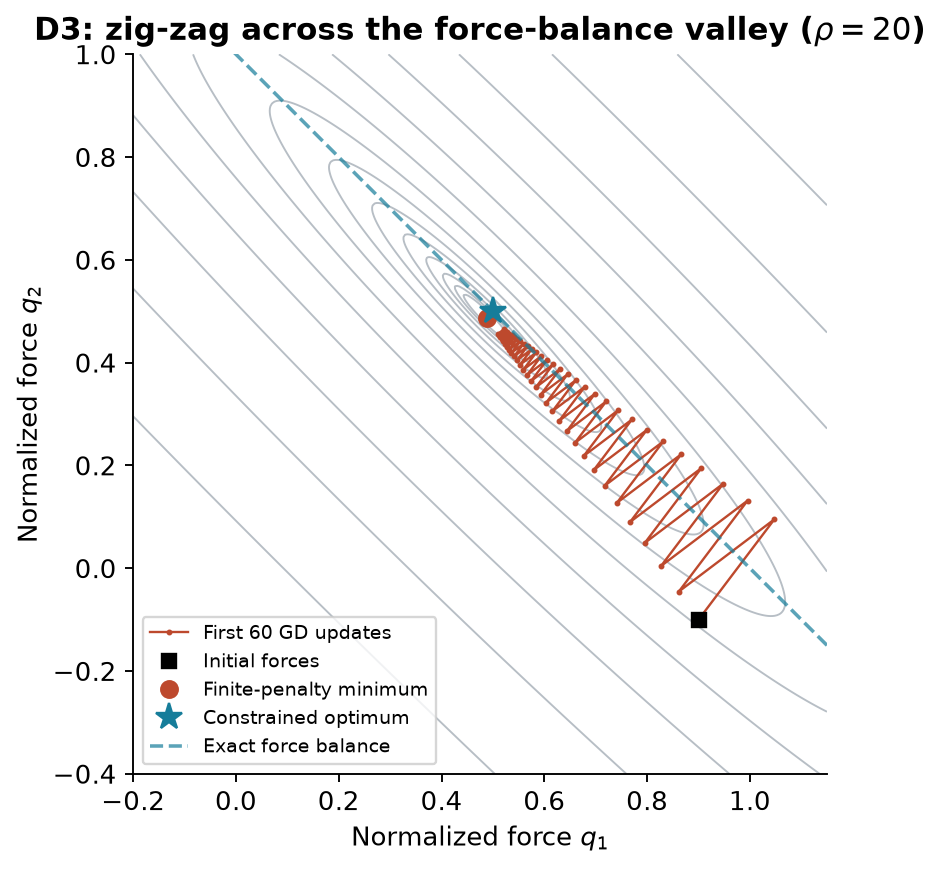

In [5]:
rho_path = 20.0
path_run = gradient_descent(lambda q: penalty_grad(q, rho_path), q0,
                           1/(1+rho_path), 1e-8, 1000)
grid1, grid2 = np.meshgrid(np.linspace(-.2, 1.15, 320), np.linspace(-.4, 1.0, 320))
Q = np.stack([grid1, grid2], axis=-1)
e = Q - penalty_solution(rho_path)
Z = 0.5 * np.einsum('...i,ij,...j->...', e, hessian(rho_path), e)
fig, ax = plt.subplots(figsize=(7, 5), layout='constrained')
ax.contour(grid1, grid2, Z, levels=np.geomspace(.002, 8, 14), colors='#b7bec5', linewidths=.8)
path = path_run['xs'][:61]
ax.plot(path[:, 0], path[:, 1], '.-', color=COLORS['penalty'], ms=3, lw=1, label='First 60 GD updates')
ax.plot(q0[0], q0[1], 's', color='black', label='Initial forces')
qp = penalty_solution(rho_path)
ax.plot(*qp, 'o', color=COLORS['penalty'], ms=7, label='Finite-penalty minimum')
ax.plot(*q_star, '*', color=COLORS['alm'], ms=12, label='Constrained optimum')
xline = np.linspace(-.2, 1.15, 100)
ax.plot(xline, 1-xline, '--', color=COLORS['alm'], alpha=.7, label='Exact force balance')
ax.set(xlabel=r'Normalized force $q_1$', ylabel=r'Normalized force $q_2$',
       title=r'D3: zig-zag across the force-balance valley ($\rho=20$)',
       xlim=(-.2,1.15), ylim=(-.4,1.0), aspect='equal')
ax.legend(fontsize=8, loc='lower left')
show_save(fig, 'd3_iterate_path')

## 5. Proposed solution and demonstration

### Augmented Lagrangian with moderate penalty

Use the augmented Lagrangian

$$\mathcal L_\beta(q,y)=J(q)+y g(q)+\frac\beta2g(q)^2,$$

and repeat

$$q^{t+1}\approx\arg\min_q\mathcal L_\beta(q,y^t),\qquad
y^{t+1}=y^t+\beta g(q^{t+1}).$$

Here $\beta=1$, $y^0=0$, and each inner minimization uses **gradient descent**, warm-started from the previous force vector. Its step is $1/(1+\beta)=1/2$, and its absolute infinity-norm gradient tolerance is $10^{-10}$. This is deliberately tighter than the common final tolerance; all inner work is counted. We use neither the analytical minimizer nor a direct linear solve inside the numerical AL algorithm.

The inner Hessian is always $I+\beta aa^\top$, with $\kappa=1+2\beta=3$. The multiplier accumulates the force-balance correction, so we do not need to send $\beta$ to infinity. This addresses the particular source of stiffness, rather than simply scaling the coordinates.

For **exact** inner solves, an independent derivation gives

$$q^{t+1}=\frac{\beta-y^t}{1+2\beta}a,\quad
y^{t+1}=\frac{y^t-\beta}{1+2\beta},\quad
y^{t+1}-y^\star=\frac{y^t-y^\star}{1+2\beta}.$$

At $\beta=1$, each outer iteration contracts the multiplier error by $1/3$, and the force deficit after outer iteration $t\ge1$ is $3^{-t}$. Thus nine exact outer solves should suffice for $10^{-4}$ feasibility. The computation checks the corresponding inexact result.

### D4: a common constrained-problem accuracy

Different penalty/AL subproblems have different objective values, so comparing those values directly would be misleading. For both methods, track the original problem's dimensionless KKT residual

$$r_{\mathrm{KKT}}(q,y)=\max\{\|q+ya\|_\infty,\ |a^\top q-1|\}.$$

Stop when **both** stationarity and feasibility are at most $\epsilon=10^{-4}$. For the pure penalty method use the implied multiplier $y=\rho g(q)$, so stationarity is precisely its penalty gradient. Choose $\rho=10^4$; its limiting force deficit is $1/20001\approx5\times10^{-5}$, comfortably below tolerance. For AL use its current multiplier.

The horizontal axis is cumulative **primal gradient updates**, including every inner update for AL. Gradient-evaluation counts and outer multiplier updates are also reported. AL checks the final stopping condition after a multiplier update. Within an inner solve, KKT curves may temporarily rise because the current primal-dual pair need not improve monotonically. Both methods start at the same $q_0$; their initial multipliers differ according to their definitions. This is a comparison of the complete algorithms, not identical dual initializations.

At $F_{\mathrm{ref}}=1000\ \mathrm N$, the feasibility tolerance is a $0.1\ \mathrm N$ total-force error. This is a chosen numerical target for the idealized model, not a validated hardware requirement.

In [6]:
def kkt_metrics(q, y):
    stationarity = float(np.max(np.abs(q + y*a)))
    feasibility = float(abs(constraint(q)))
    return stationarity, feasibility, max(stationarity, feasibility)

COMMON_TOL = 1e-4
RHO_COMPARE = 10000.0
BETA = 1.0
INNER_TOL = 1e-10

def solve_penalty_common(rho, x0, tol, maxit=300000):
    q = x0.copy()
    qs, ys, metrics = [], [], []
    start = time.perf_counter()
    for k in range(maxit+1):
        y = rho * constraint(q)
        g = q + y*a
        m = (float(np.max(np.abs(g))), float(abs(constraint(q))))
        qs.append(q.copy()); ys.append(y); metrics.append((*m, max(m)))
        if max(m) <= tol:
            return dict(qs=np.array(qs), ys=np.array(ys), metrics=np.array(metrics),
                        work=np.arange(k+1), updates=k, grad_evals=k+1,
                        seconds=time.perf_counter()-start, outer=0)
        if k == maxit: raise RuntimeError('Penalty comparison did not converge.')
        q -= g / (1+rho)

def solve_alm(beta, x0, tol, inner_tol, max_outer=50):
    q, y = x0.copy(), 0.0
    work, qs, ys, metrics, events = [0], [q.copy()], [y], [kkt_metrics(q,y)], ['initial']
    updates = grad_evals = 0
    outer_rows = []
    start = time.perf_counter()
    for outer in range(1, max_outer+1):
        before = updates
        for inner in range(1000):
            grad = q + (y + beta*constraint(q))*a
            grad_evals += 1
            if np.max(np.abs(grad)) <= inner_tol: break
            q -= grad / (1+beta)
            updates += 1
            work.append(updates); qs.append(q.copy()); ys.append(y)
            metrics.append(kkt_metrics(q,y)); events.append('primal')
        else: raise RuntimeError('AL inner solve did not converge.')
        y += beta*constraint(q)
        work.append(updates); qs.append(q.copy()); ys.append(y)
        metrics.append(kkt_metrics(q,y)); events.append('dual')
        outer_rows.append([outer, updates-before, updates, y, *metrics[-1]])
        if metrics[-1][-1] <= tol:
            return dict(qs=np.array(qs), ys=np.array(ys), metrics=np.array(metrics),
                        work=np.array(work), events=events, updates=updates, grad_evals=grad_evals,
                        outer=outer, outer_rows=outer_rows, seconds=time.perf_counter()-start)
    raise RuntimeError('AL outer loop did not converge.')

pure = solve_penalty_common(RHO_COMPARE, q0, COMMON_TOL)
alm = solve_alm(BETA, q0, COMMON_TOL, INNER_TOL)
comparison_rows = []
for name, run, cond in [('Penalty GD', pure, 1+2*RHO_COMPARE), ('Augmented Lagrangian + GD', alm, 1+2*BETA)]:
    comparison_rows.append([name, int(cond), run['updates'], run['grad_evals'], run['outer'],
                            f'{run["metrics"][-1,0]:.3e}', f'{run["metrics"][-1,1]:.3e}',
                            f'{F_REF*run["metrics"][-1,1]:.5f}'])
table(['Method', 'Inner kappa', 'Primal updates', 'Gradient evaluations', 'Dual updates',
       'Stationarity', 'Feasibility', 'Force error (N)'], comparison_rows)
save_csv('method_comparison.csv', ['method', 'inner_kappa', 'primal_updates', 'gradient_evaluations',
                                 'dual_updates', 'stationarity', 'feasibility', 'force_error_N'], comparison_rows)
save_csv('alm_outer_iterations.csv', ['outer', 'inner_updates', 'cumulative_updates', 'multiplier',
                                     'stationarity', 'feasibility', 'kkt_residual'], alm['outer_rows'])
for name, run in [('Penalty GD', pure), ('AL + GD', alm)]:
    print(f'{name}: final forces = {F_REF*run["qs"][-1]} N; elapsed = {run["seconds"]:.4f} s')
print('Elapsed times are descriptive only; iteration counts are the reproducible work measure.')

| Method | Inner kappa | Primal updates | Gradient evaluations | Dual updates | Stationarity | Feasibility | Force error (N) |
|---|---|---|---|---|---|---|---|
| Penalty GD | 20001 | 168122 | 168123 | 0 | 9.999e-05 | 5.001e-05 | 0.05001 |
| Augmented Lagrangian + GD | 3 | 246 | 255 | 9 | 7.268e-11 | 5.081e-05 | 0.05081 |

Penalty GD: final forces = [499.97502125 499.97497125] N; elapsed = 1.9897 s
AL + GD: final forces = [499.97459739 499.97459739] N; elapsed = 0.0036 s
Elapsed times are descriptive only; iteration counts are the reproducible work measure.


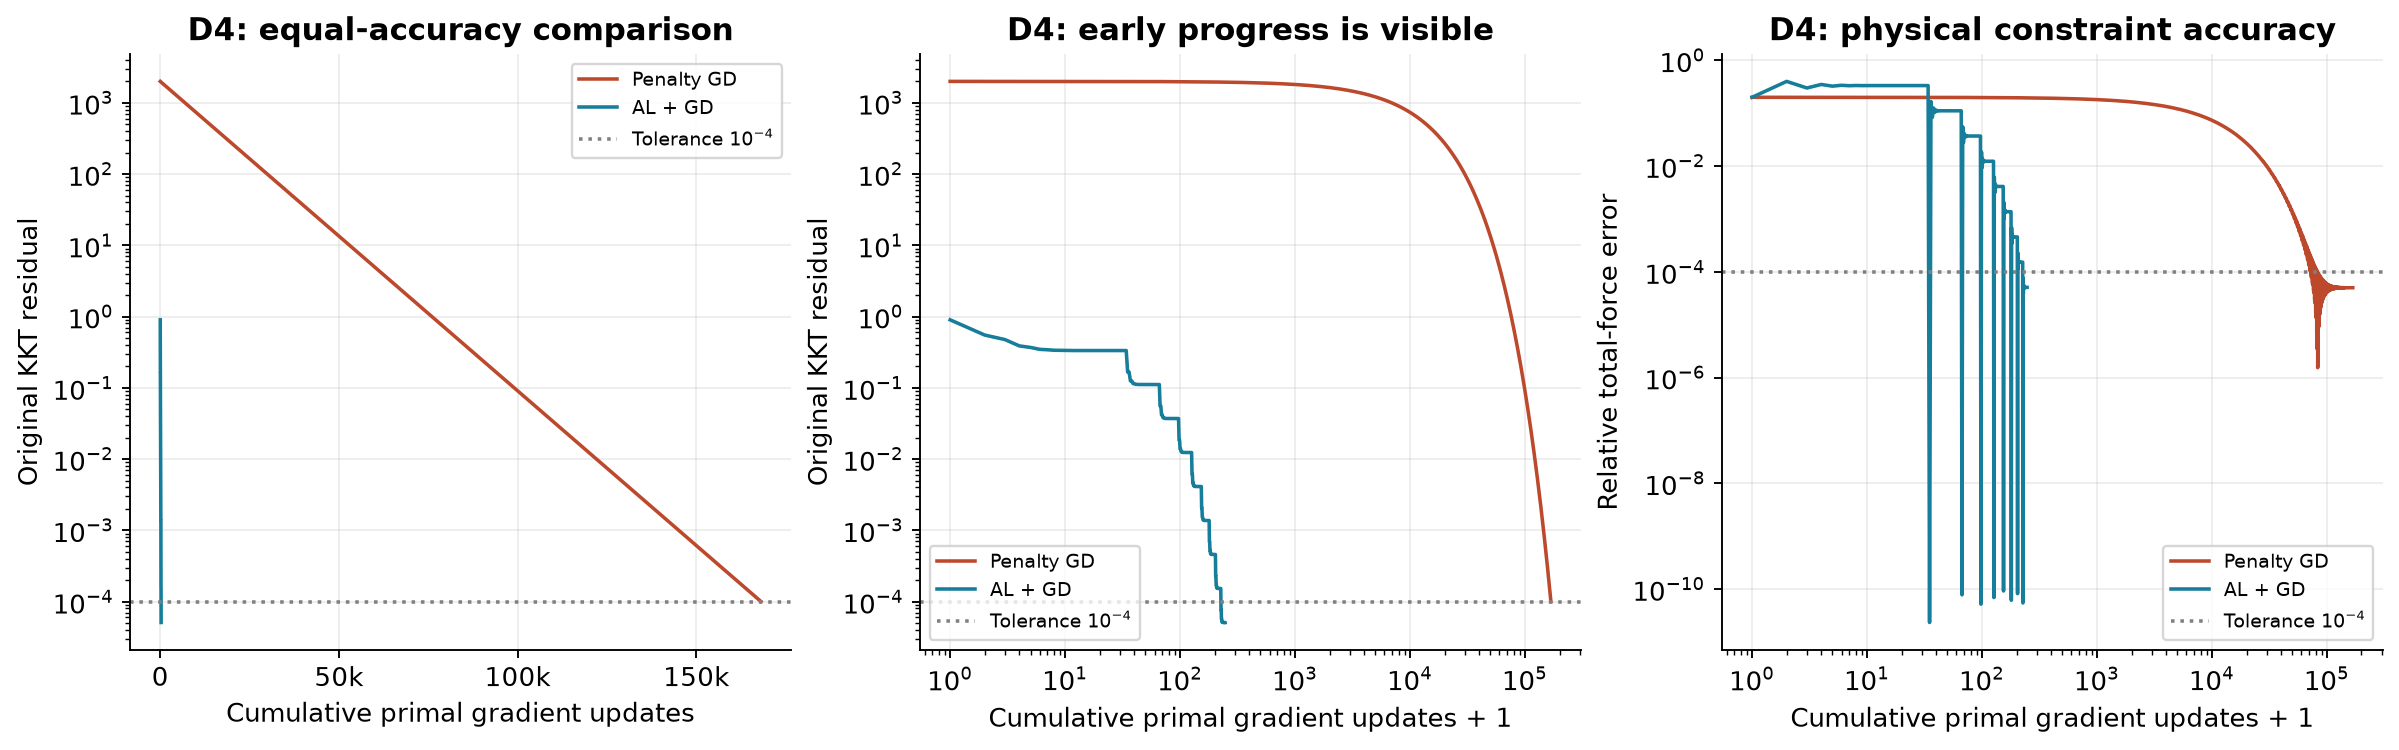

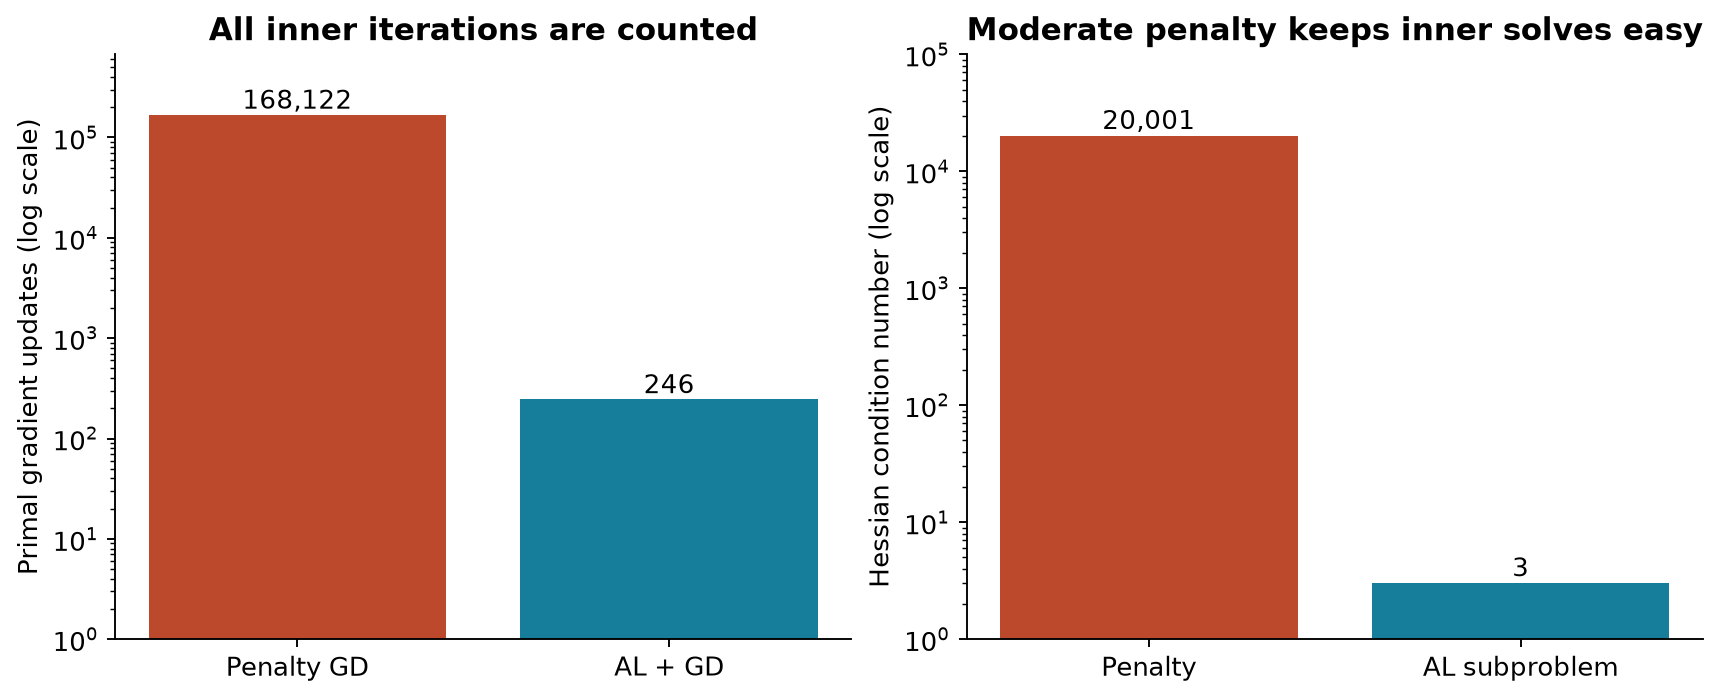

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.3), layout='constrained')
for name, run, color in [('Penalty GD', pure, COLORS['penalty']), ('AL + GD', alm, COLORS['alm'])]:
    idx = np.unique(np.linspace(0, len(run['work'])-1, min(2400, len(run['work'])), dtype=int))
    ax[0].semilogy(run['work'][idx], np.maximum(run['metrics'][idx,2], 1e-16), color=color, label=name)
    # Same data on a log-work axis reveals the early AL behavior. +1 retains the start.
    ax[1].loglog(run['work'][idx]+1, np.maximum(run['metrics'][idx,2], 1e-16), color=color, label=name)
    ax[2].loglog(run['work'][idx]+1, np.maximum(run['metrics'][idx,1], 1e-16), color=color, label=name)
for axis in ax:
    axis.axhline(COMMON_TOL, ls=':', color='gray', label=r'Tolerance $10^{-4}$')
    axis.grid(alpha=.22); axis.legend(fontsize=8)
ax[0].set(xlabel='Cumulative primal gradient updates', ylabel='Original KKT residual', title='D4: equal-accuracy comparison')
ax[1].set(xlabel='Cumulative primal gradient updates + 1', ylabel='Original KKT residual', title='D4: early progress is visible')
ax[2].set(xlabel='Cumulative primal gradient updates + 1', ylabel='Relative total-force error', title='D4: physical constraint accuracy')
readable_work_axis(ax[0])
show_save(fig, 'd4_common_accuracy')

fig, ax = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
ax[0].bar(['Penalty GD', 'AL + GD'], [pure['updates'], alm['updates']], color=[COLORS['penalty'], COLORS['alm']])
ax[0].set(yscale='log', ylabel='Primal gradient updates (log scale)', title='All inner iterations are counted')
for i, n in enumerate([pure['updates'], alm['updates']]): ax[0].text(i, n*1.15, f'{n:,}', ha='center')
ax[0].set_ylim(1, pure['updates']*4)
ax[1].bar(['Penalty', 'AL subproblem'], [1+2*RHO_COMPARE, 1+2*BETA], color=[COLORS['penalty'], COLORS['alm']])
ax[1].set(yscale='log', ylabel='Hessian condition number (log scale)', title='Moderate penalty keeps inner solves easy')
for i, val in enumerate([1+2*RHO_COMPARE, 1+2*BETA]): ax[1].text(i, val*1.15, f'{val:,.0f}', ha='center')
ax[1].set_ylim(1, 1e5)
show_save(fig, 'd4_work_and_conditioning')

### Verification and interpretation

The assertions below independently check eigenvalues, the analytic finite-penalty optimizer, a directional derivative, the hand-calculated first update and iteration count, and the final KKT residuals. The AL outer feasibility sequence is compared with the exact $3^{-t}$ prediction, allowing for the inner solve tolerance. These checks target mathematical correctness and stopping behavior.

The narrow dips in the force-error curve occur when iterates cross the force-balance line. A temporarily small force error does not establish optimality: stationarity must also be small, which is why the stopping rule checks both quantities.

A direct KKT solve is included only as a verification reference. For two actuators it is the most practical solution; the iterative comparison is intended to expose and explain the conditioning mechanism. The large iteration reduction should not be read as a universal runtime advantage over direct methods or over all penalty solvers.

In [8]:
np.testing.assert_allclose(spectrum(hessian(1))[0], [1, 3])
np.testing.assert_allclose(cond_after_diagonal_rescale(hessian(1)), 3)
np.testing.assert_allclose(q0 - .5*penalty_grad(q0, 1), [.55, .05], atol=1e-15)
assert baseline[1]['updates'] == 20
for rho in [1, 10, 1000, 10000]:
    np.testing.assert_allclose(np.linalg.solve(hessian(rho), rho*a), penalty_solution(rho), rtol=1e-11)

probe, direction, step = np.array([.3, -.2]), np.array([.4, .7]), 1e-6
fd = (penalty(probe+step*direction, 7)-penalty(probe-step*direction, 7))/(2*step)
np.testing.assert_allclose(fd, penalty_grad(probe, 7)@direction, rtol=1e-8)

KKT = np.block([[np.eye(2), a[:,None]], [a[None,:], np.zeros((1,1))]])
reference = np.linalg.solve(KKT, np.array([0., 0., 1.]))
np.testing.assert_allclose(reference, [.5, .5, -.5], atol=1e-15)
for run in [pure, alm]:
    assert run['metrics'][-1,2] <= COMMON_TOL
    assert np.all(np.isfinite(run['qs']))
    # Feasibility + stationarity bounds imply this force-vector error bound.
    assert np.max(np.abs(run['qs'][-1]-q_star)) <= 1.5*COMMON_TOL
assert pure['metrics'][-2,2] > COMMON_TOL
assert alm['outer'] == 9
dual_indices = np.flatnonzero(np.array(alm['events']) == 'dual')
np.testing.assert_allclose(alm['metrics'][dual_indices,1], 3.0**(-np.arange(1, alm['outer']+1)), atol=3e-10, rtol=0)
assert alm['grad_evals'] == alm['updates'] + alm['outer']
assert pure['grad_evals'] == pure['updates'] + 1

speedup = pure['updates']/alm['updates']
summary = {
    'seed': SEED, 'common_tolerance': COMMON_TOL, 'penalty_rho': RHO_COMPARE, 'alm_beta': BETA,
    'inner_tolerance': INNER_TOL, 'q0': q0.tolist(),
    'penalty_updates': pure['updates'], 'alm_updates': alm['updates'], 'alm_outer_iterations': alm['outer'],
    'primal_update_ratio': speedup,
    'penalty_final_kkt': float(pure['metrics'][-1,2]), 'alm_final_kkt': float(alm['metrics'][-1,2]),
    'penalty_forces_N': (F_REF*pure['qs'][-1]).tolist(), 'alm_forces_N': (F_REF*alm['qs'][-1]).tolist(),
    'python': platform.python_version(), 'numpy': np.__version__, 'matplotlib': matplotlib.__version__,
    'all_checks_passed': True,
}
(OUT/'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print('All analytical, derivative, update-count, and convergence checks passed.')
display(Markdown(f"""**Measured result:** penalty GD required **{pure['updates']:,} primal updates**, versus
**{alm['updates']:,}** across **{alm['outer']} outer iterations** for AL + GD: approximately
**{speedup:,.1f} times fewer primal updates** at the same KKT tolerance. The inner condition number fell
from **{1+2*RHO_COMPARE:,.0f}** to **{1+2*BETA:.0f}**. This ratio is specific to the stated model, starting point,
step sizes, and tolerances; it is not a measured universal speedup."""))

All analytical, derivative, update-count, and convergence checks passed.


**Measured result:** penalty GD required **168,122 primal updates**, versus
**246** across **9 outer iterations** for AL + GD: approximately
**683.4 times fewer primal updates** at the same KKT tolerance. The inner condition number fell
from **20,001** to **3**. This ratio is specific to the stated model, starting point,
step sizes, and tolerances; it is not a measured universal speedup.

## 6. Assumptions and simplifications

- **Identical, ideal actuators:** the quadratic effort weights are equal and positive. Different actuator constants would change the optimal split and Hessian; those cases are outside this experiment.
- **Static axial balance:** a guide handles lateral forces and moments. We omit inertia, vibration, friction, actuator dynamics, communication delays, and controller stability.
- **Bidirectional continuous forces:** negative intermediate forces are allowed. The optimizer starts at $(900,-100)\ \mathrm N$ and ends close to $(500,500)\ \mathrm N$. If a real device can only push, or has finite capacity, explicit bounds and a suitable constrained solver are needed.
- **Numerical iterates are not hardware commands:** intermediate loads can violate balance. This notebook is an offline optimization study, not an implementation of a safe real-time force controller.
- **Quadratic loss proxy:** the objective represents an idealized resistive-effort model. It omits mechanical power, saturation, efficiency variation, heating feedback, and measured calibration data.
- **Fixed load and exact derivatives:** demand is known and constant. There is no measurement noise, uncertainty model, or derivative-estimation error.
- **Small system:** closed-form allocation and a direct KKT solve are available. Two variables make the geometry and manual verification transparent; practical benefits for larger systems would require separate evidence.
- **Conditioning is formulation-dependent:** the original constrained problem is well behaved; the large condition number belongs to the finite-penalty objective. The augmented Lagrangian uses a sequence of well-conditioned subproblems, not a single identical objective with a magically smaller Hessian.
- **Accuracy and work:** D3 uses relative gradient tolerance for each penalty objective. D4 uses one absolute, dimensionless KKT tolerance for the original constrained problem. We report primal updates, gradient evaluations, and dual updates; machine-dependent elapsed times are secondary.

**Conclusion.** Increasing force-balance penalty weight creates an eigenvalue split that survives Jacobi scaling and slows gradient descent. The augmented Lagrangian maintains a moderate penalty while adjusting the multiplier, attaining comparable force balance and optimality with much less first-order work in this example.

### Source and reproducibility notes

The assignment's family G formulation, intrinsic-conditioning test, D1-D4 diagnostic protocol, and generic spectrum/gradient-descent helpers informed this project: [Project 2: Ill-Conditioned Optimization](https://designinformaticslab.github.io/DesignOptimization2025/project2.html), supplied as PDF and Markdown by the student. The hand derivations and numerical results above specialize that protocol to the actuator model. No external experimental dataset is used.

AI assistance was used to draft the model exposition, diagnostic code, and report. The included executable checks verify the stated small-case mathematics and numerical convergence; students should be able to reproduce and explain those checks. Add the team member names and follow any course-specific disclosure requirements before submission.

The submission artifact is this **single notebook**, containing the complete report, runnable code, and saved outputs. The assignment additionally requires a **public team GitHub repository** and submission of its link on **Canvas**. Those publication/submission actions are not performed by this notebook.